# Generación de datos de entrenamiento

Este notebook es una guía rápida para generar el dataset necesario para entrenar modelos de ML mediante aprendizaje supervisado. Dividiremos el proceso en tres bloques:

1. **Generación de instancias**
2. **Generación de datos**
3. **Implementación de nuevos adaptadores**

## Generación de instancias

En el contexto del **CPMP**, definimos una instancia según tres parámetros clave:

-   **S (Stacks):** Número de stacks disponibles.
-   **H (Height):** Altura máxima permitida para cada stack.
-   **N (Nodes/Containers):** Número total de contenedores.

Para crear estas configuraciones, el framework utiliza **Generadores**. La elección del generador es crítica, ya que determina el "ruido" y la dificultad de los datos con los que aprenderá el modelo.

### Tipos de Generators disponibles:

-   **FullRandomGenerator**: Genera layouts con una distribución de contenedores completamente aleatoria.
-   **RandomMovesGenerator**: Parte de un layout ya ordenado y aplica r movimientos aleatorios para desordenarlo de forma controlada.
-   **UniformCostGenerator**: Una versión adaptativa del anterior para buscar un balance de dificultad. **Nota:** Está restringido a configuraciones donde $N=S×(H-2)$.

### Ejecución de la generación

Para llevar a cabo el proceso, emplearemos la función `generate_instances`. En ella, definiremos el `basename` (directorio de salida), el `generator` previamente configurado y el `amount` o cantidad de instancias que deseamos obtener.

#### Ejemplo 1: FullRandom

Se suele utilizar para escenarios donde se busca el máximo desorden posible en el _layout_.

In [8]:
from generation.instances import generate_instances, FullRandomGenerator

fr_generator = FullRandomGenerator(H=7, S=5, N=25, seed=42)
generate_instances(basename="ejemplo_fr", generator=fr_generator, amount=100)

Instancias guardadas en: /home/oscar/Escritorio/CPMP-Framework/instances/ejemplo_fr


#### Ejemplo 2: RandomMoves

Este enfoque es útil cuando queremos simular un desorden basado en movimientos físicos reales sobre un _stack_ inicialmente ordenado.

In [2]:
from generation.instances import generate_instances, RandomMovesGenerator

rm_generator = RandomMovesGenerator(H=7, S=5, N=25, r=100, seed=42)
generate_instances(basename="ejemplo_rm", generator=rm_generator, amount=100)

Instancias guardadas en: /home/oscar/Escritorio/CPMP-Framework/instances/ejemplo_rm


#### Ejemplo 3: UniformCost

Este generador es ideal cuando buscamos entrenar el modelo con un espectro de dificultad variable. Su ventaja es que calibra las instancias basándose en el número de movimientos necesarios para resolverlas, lo que nos permite obtener un dataset con una dificultad técnica balanceada.

In [13]:
from generation.instances import generate_instances, UniformCostGenerator

uc_generator = UniformCostGenerator(H=7, S=5, seed=42)
generate_instances(basename="ejemplo_uc", generator=uc_generator, amount=2000)

Instancias guardadas en: /home/oscar/Escritorio/CPMP-Framework/instances/ejemplo_uc


## Generación de datos

En esta etapa, transformamos las instancias en conocimiento para el modelo. El proceso consiste en resolver las instancias mediante un **solver** para obtener las soluciones óptimas y, a partir de ellas, generar pares de entrada-salida (_features_ y _labels_).

Para flexibilizar cómo el modelo "ve" el problema, utilizaremos diferentes **adaptadores**.

### Input Adapters

Estos componentes definen la representación del _layout_ que recibirá el modelo.

#### LayoutAdapter (Matriz de stacks)

Representan el estado de los contenedores en las pilas. Disponemos de tres versiones:

-   **V1:** Enfocada en el orden lógico. Incluye el _group value_ y dos variables binarias (`valid_top` y `valid_bottom`) que indican si un contenedor respeta el orden respecto al contenedor superior e inferior.
-   **V2:** Enfocada en la estructura espacial. Incluye el _group value_ y métricas de posición: `depth` (profundidad en el _stack_ actual) y `pos` (posición relativa a la altura máxima $H_{max}​$).
-   **V3:** Una combinación integral que incluye todas las _features_ de V1 y V2.

#### StackFeaturesAdapter (Atributos del stack)

Si la arquitectura del modelo lo permite, podemos extraer métricas globales por cada pila. Actualmente implementamos:

-   **V1:** Proporciona una visión general mediante `is_sorted` (binario), `height_ratio` ($H$/$H_{max}$​) y `sorted_ratio` (proporción de la base que ya está correctamente ordenada).

> **Tip:** Para combinar ambas perspectivas (contenedores + stacks), utilizaremos el **EnrichedLayoutAdapter**, el cual integra un objeto de cada clase para generar un _input_ más robusto.

### Output Adapters

Definen qué es lo que el modelo debe predecir:

-   **ActionAdapter:** El modelo intenta predecir la siguiente **acción** óptima (el movimiento de un contenedor desde un _stack_ de origen a uno de destino).
-   **CostAdapter:** El modelo estima el **costo** total, es decir, el número de pasos restantes para resolver el _layout_.

### Función generadora y procesamiento

Para producir el dataset de entrenamiento bajo un esquema de aprendizaje supervisado, utilizaremos la función `generate_data_sl`. En el siguiente bloque, configuramos los adaptadores y definimos el paralelismo mediante `num_workers`.

In [3]:
from generation.data import generate_data_sl
from generation.adapters.input import EnrichedLayoutAdapter, Layout4DAdapterV2
from generation.adapters.input.stack_features import StackFeaturesAdapterV1
from generation.adapters.output import ActionAdapter
from solvers import FRGSolver

# Configuración del proceso
folder = "ejemplo_fr"
H = 7
max_steps = 50
num_workers = 12
output_prefix = None

# Definimos la combinación de adaptadores
input_adapter_config = (EnrichedLayoutAdapter, Layout4DAdapterV2, StackFeaturesAdapterV1, 10, 8)
output_adapter_config = (ActionAdapter, )

# Configuración del solver
solver_config = (FRGSolver, )

# Ejecutamos la generación de datos transformando las soluciones del solver
generate_data_sl(folder, H, max_steps, input_adapter_config, output_adapter_config, solver_config, num_workers, output_prefix)

Datos guardados en: /home/oscar/Escritorio/CPMP-Framework/data/ejemplo_fr.data (Tamaño 100)


### Creación de Datasets específicos

Una vez generados los archivos de datos base, utilizaremos la función `generate_dataset` para filtrar, limitar o balancear la información que realmente llegará al modelo.

#### Caso 1: Filtrado estándar por costo

En este primer ejemplo, creamos un dataset acotado. Es muy útil cuando queremos que el modelo se enfoque en un rango de dificultad específico (por ejemplo, instancias que no sean ni triviales ni extremadamente complejas).

In [1]:
from preprocessing.dataset import generate_dataset

data_files = ["ejemplo_fr.data"]
max_size = 50       # Limitamos a 50 muestras totales
min_cost = 5        # Solo instancias que requieran al menos 5 movimientos
max_cost = 30       # Y como máximo 30
output_name = "dataset_ejemplo_fr.data"

generate_dataset(data_files, output_name, min_cost, max_cost, max_size)

Dataset generado exitosamente en: /home/oscar/Escritorio/CPMP-Framework/data/dataset_ejemplo_fr.data (Tamaño 49)


#### Caso 2: Dataset balanceado

Al activar `balanced`, el framework identifica el costo con menos muestras y recorta el resto para igualarlos. Esto permite generar una **distribución uniforme**, garantizando que el modelo aprenda de cada nivel de dificultad por igual sin sesgarse hacia los casos más frecuentes.

> **Tip:** Lo ideal es emplear esta opción junto al **UniformCostGenerator**. De esta manera, aseguramos variedad técnica desde la raíz y un equilibrio estadístico total en el dataset final.

Datos guardados en: /home/oscar/Escritorio/CPMP-Framework/data/ejemplo_uc.data (Tamaño 2000)
Dataset generado exitosamente en: /home/oscar/Escritorio/CPMP-Framework/data/dataset_ejemplo_uc.data (Tamaño 1000)


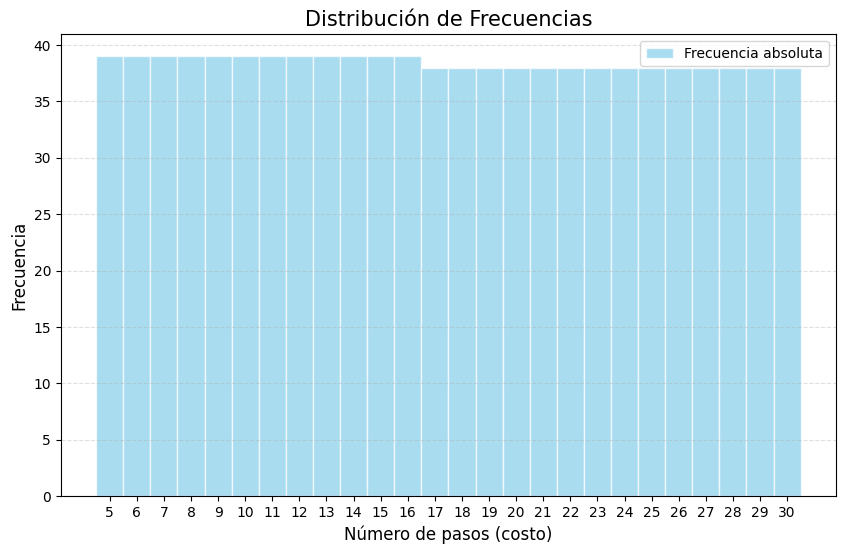

In [4]:
from preprocessing.dataset import generate_dataset
from analysis import plot_counts

# Generación de datos
generate_data_sl("ejemplo_uc", 7, 50, input_adapter_config, output_adapter_config, solver_config, 12, output_prefix)

# Configuración y ejecución del balanceo
generate_dataset(
    data_files=["ejemplo_uc.data"], 
    output_name="dataset_ejemplo_uc.data", 
    min_cost=5, max_cost=30, max_size=1000, 
    balance_method='cost'
)

# Verificación de la distribución resultante
plot_counts("dataset_ejemplo_uc.data")

## Implementación de nuevos adaptadores

Si estamos experimentando con nuevas arquitecturas, es probable que necesitemos definir formatos de entrada personalizados. Por ejemplo, supongamos que queremos representar cada contenedor con su valor de grupo normalizado c y una nueva _feature_ correspondiente a log(c).

Para ello, implementaremos la clase `CustomLayoutAdapter` heredando de `LayoutAdapter`. El método principal a definir es `input_2_vec`, el cual transforma un objeto `Layout` en un tensor numérico.

Esta función gestiona dos aspectos críticos:

1.  **Extracción de features:** La lógica de cálculo para cada celda.
2.  **Padding:** El uso de Smax​ y Hmax​ para asegurar que el modelo reciba siempre tensores de tamaño fijo, independientemente de la instancia.

In [14]:
import numpy as np
from generation.adapters.input.layout.layout_adapter import LayoutAdapter

class CustomLayoutAdapter(LayoutAdapter):
    def __init__(self, S_max, H_max):
        super().__init__(S_max, H_max)

    def input_2_vec(self, layout, H):
        stacks_matrix = []
        
        # Obtenemos el valor máximo para normalizar
        all_vals = [c for s in layout.stacks for c in s]
        max_val = max(all_vals) if all_vals else 1

        # 1. Procesamiento y Padding de ALTURA (H_max)
        for i in range(len(layout.stacks)):
            stack = []
            for j in range(len(layout.stacks[i])):
                val = layout.stacks[i][j]
                normalized_c = val / max_val
                # Nueva feature sugerida: log(c) (usamos log1p para evitar log(0))
                log_c = np.log1p(val) 
                
                # Cada celda tendrá 2 valores: [c_norm, log_c]
                stack.append([normalized_c, log_c])
            
            # Aplicamos padding a la pila actual rellenando con -1.0
            padding_size = self.H_max - len(stack)
            padded_stack = stack[:self.H_max] + [[-1.0, -1.0]] * max(0, padding_size)
            stacks_matrix.append(padded_stack)

        # 2. Padding de STACKS (S_max)
        num_current_stacks = len(stacks_matrix)
        stacks_to_add = self.S_max - num_current_stacks
        
        if stacks_to_add > 0:
            # Rellenamos con stacks vacíos de tamaño (H_max, 2)
            empty_stack = [[-1.0, -1.0]] * self.H_max
            for _ in range(stacks_to_add):
                stacks_matrix.append(empty_stack)
        else:
            stacks_matrix = stacks_matrix[:self.S_max]

        # El resultado final tendrá un shape de (S_max, H_max, 2)
        return (np.array(stacks_matrix, dtype=np.float32), )

### Uso del adaptador personalizado

Una vez definida la clase, la integramos en el flujo de generación como cualquier otro adaptador.

In [15]:
from generation.data import generate_data_sl
from generation.adapters.output import ActionAdapter
from solvers import FRGSolver

# Configuramos la generación usando nuestro nuevo adaptador
input_adapter_config = (CustomLayoutAdapter, 10, 8)
output_adapter_config = (ActionAdapter, )
solver_config = (FRGSolver, )

generate_data_sl(
    folder="ejemplo_fr", 
    H=7, 
    max_steps=50, 
    input_adapter_config=input_adapter_config, 
    output_adapter_config=output_adapter_config, 
    solver_config=solver_config,
    num_workers=12, 
    output_name_prefix="custom"
)

Datos guardados en: /home/oscar/Escritorio/CPMP-Framework/data/custom_ejemplo_fr.data (Tamaño 100)


### Verificación de los datos

Para asegurar que las _features_ se calcularon correctamente, podemos cargar una muestra del archivo generado y visualizar el contenido de una pila.

In [16]:
from preprocessing.dataset import load_data

# Cargamos el archivo para inspeccionar la estructura
data = load_data("custom_ejemplo_fr.data")
idx = 0

print("Representación de una pila (Stack 0):")
print("Format: [c_norm, log(c)]")
# Mostramos la primera pila del primer ejemplo
print(data['input/S'][idx][0])

Representación de una pila (Stack 0):
Format: [c_norm, log(c)]
[[ 0.76       2.9957323]
 [ 0.44       2.4849067]
 [ 0.08       1.0986123]
 [ 0.16       1.609438 ]
 [ 0.48       2.5649493]
 [ 0.84       3.0910425]
 [-1.        -1.       ]
 [-1.        -1.       ]]
